In [27]:
#import libraries
import textwrap
from pathlib import Path
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [28]:
#basic styling
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,4)

In [29]:
#file path
csv_path = Path("data") / "archive" / "Amazon Sale Report.csv"

In [30]:
#dataset loading with fallback on encoding
df = pd.read_csv(csv_path, encoding="utf-8", low_memory=False)

In [31]:
#brief check
print(df.shape)
print(df.columns)
df.head()

(128975, 24)
Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [32]:
#types and nulls
df.info()
df.isna().sum().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

fulfilled-by        89698
promotion-ids       49153
Unnamed: 22         49050
currency             7795
Amount               7795
Courier Status       6872
ship-country           33
ship-city              33
ship-state             33
ship-postal-code       33
dtype: int64

In [33]:
#duplicates
dup = df.duplicated().sum()
print("Duplicates:", dup)
if dup:
    df = df.drop_duplicates()

Duplicates: 0


In [34]:
#dates
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d", errors="coerce")

#columns for graphs
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["MonthName"] = df["Date"].dt.month_name()


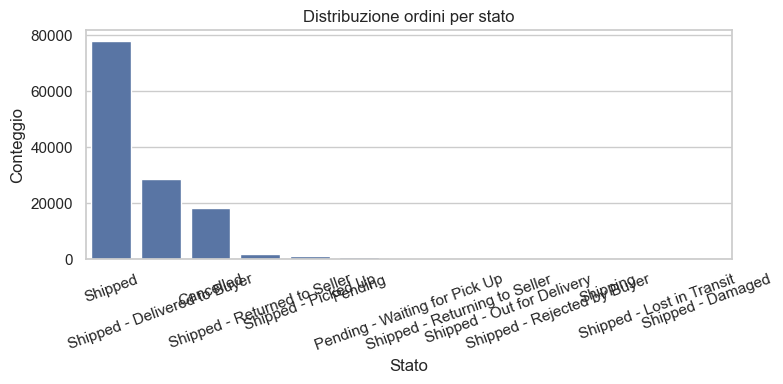

In [35]:
if col in df.columns:
    ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    ax.set_title("Distribuzione ordini per stato")
    ax.set_xlabel("Stato")
    ax.set_ylabel("Conteggio")
    plt.xticks(rotation=20)           # evita etichette sovrapposte
    plt.tight_layout()
    plt.show()


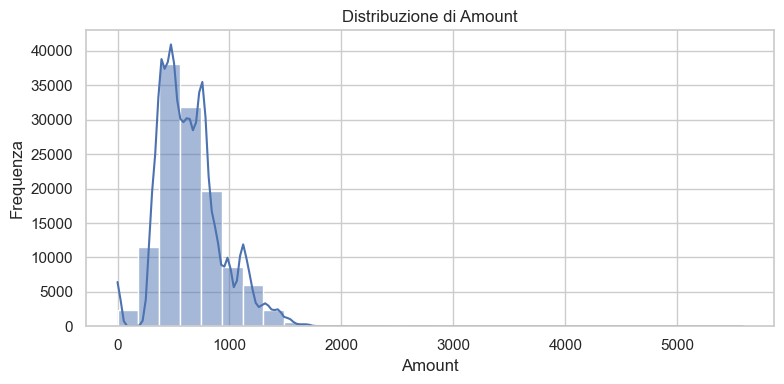

In [36]:
num_col = "Amount"
if num_col in df.columns:
    # rimuovi NaN per un istogramma pulito
    vals = df[num_col].dropna()
    sns.histplot(vals, bins=30, kde=True)  # kde=True disegna la stima della densità
    plt.title(f"Distribuzione di {num_col}")
    plt.xlabel(num_col)
    plt.ylabel("Frequenza")
    plt.tight_layout()
    plt.show()
else:
    print(f"Colonna {num_col} non trovata.")


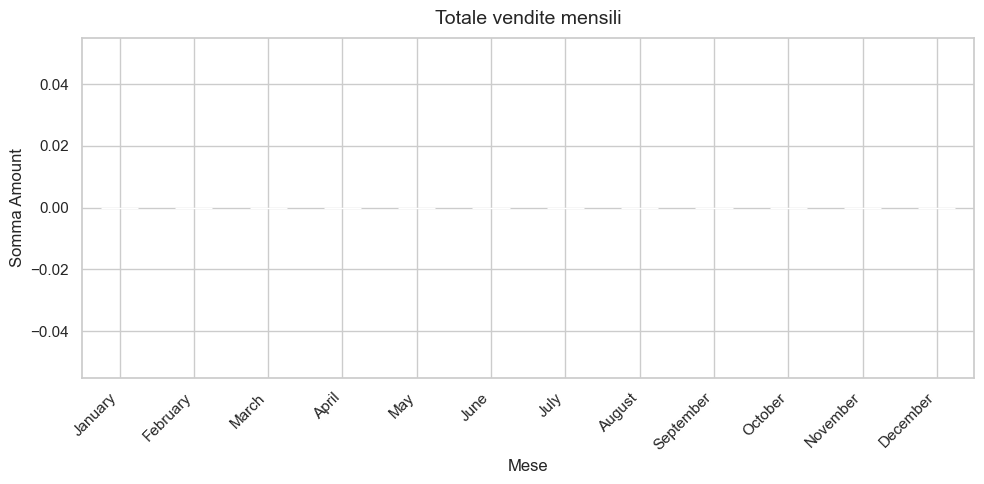

In [46]:

# Conversione robusta amount
df["Amount"] = (
    df["Amount"].astype(str)
    .str.replace("[^0-9.]", "", regex=True)
    .replace("", 0)
    .astype(float)
)

# Ricrea mese numerico e nome mese
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Month"] = df["Date"].dt.month
df["MonthName"] = df["Date"].dt.month_name()

# Raggruppa e ordina
monthly = df.groupby("MonthName")["Amount"].sum().reindex([
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
])

# Grafico a barre
plt.figure(figsize=(10,5))
ax = monthly.plot(kind="bar", color="#4f46e5")
ax.set_title("Totale vendite mensili", fontsize=14, pad=10)
ax.set_xlabel("Mese")
ax.set_ylabel("Somma Amount")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
